In [1]:
# import stone
import matplotlib.pyplot as plt 
import os
import cv2
import mtcnn
from mtcnn.mtcnn import MTCNN
import numpy as np
import time

In [2]:
def crop_and_resize(image, target_w=224, target_h=224):
    '''this function crop & resize images to target size by keeping aspect ratio'''
    if image.ndim == 2:
        img_h, img_w = image.shape             # for Grayscale will be   img_h, img_w = img.shape
    elif image.ndim == 3:
        img_h, img_w, channels = image.shape   # for RGB will be   img_h, img_w, channels = img.shape
    target_aspect_ratio = target_w/target_h
    input_aspect_ratio = img_w/img_h

    if input_aspect_ratio > target_aspect_ratio:
        resize_w = int(input_aspect_ratio*target_h)
        resize_h = target_h
        img = cv2.resize(image, (resize_w , resize_h))
        crop_left = int((resize_w - target_w)/2)  ## crop left/right equally
        crop_right = crop_left + target_w
        new_img = img[:, crop_left:crop_right]
    if input_aspect_ratio < target_aspect_ratio:
        resize_w = target_w
        resize_h = int(target_w/input_aspect_ratio)
        img = cv2.resize(image, (resize_w , resize_h))
        crop_top = int((resize_h - target_h)/4)   ## crop the top by 1/4 and bottom by 3/4 -- can be changed
        crop_bottom = crop_top + target_h
        new_img = img[crop_top:crop_bottom, :]
    if input_aspect_ratio == target_aspect_ratio:
        new_img = cv2.resize(image, (target_w, target_h))

    return new_img


In [3]:
detector = MTCNN()  # creates detector  

def extract_face(img, target_size=(224,224)):
    '''this functions extract the face from different images by 
    1) finds the facial bounding box
    2) slightly expands top & bottom boundaries to include the whole face
    3) crop into a square shape
    4) resize to target image size for modelling
    5) if the facial bounding box in step 1 is not found, image will be cropped & resized to 224x224 square'''
           
    # 1. detect faces in an image
      
    results = detector.detect_faces(img)
    if results == []:    # if face is not detected, call function to crop & resize by keeping aspect ratio
        new_face = crop_and_resize(img, target_w=224, target_h=224)    
    else:
        x1, y1, width, height = results[0]['box']
        x2, y2 = x1+width, y1+height
        face = img[y1:y2, x1:x2]  # this is the face image from the bounding box before expanding bbox

        # 2. expand the top & bottom of bounding box by 10 pixels to ensure it captures the whole face
        adj_h = 10

        #assign value of new y1
        if y1-adj_h <10:
            new_y1=0
        else:
            new_y1 = y1-adj_h

        #assign value of new y2    
        if y1+height+adj_h < img.shape[0]:
            new_y2 = y1+height+adj_h
        else:
            new_y2 = img.shape[0]
        new_height = new_y2 - new_y1

        # 3. crop the image to a square image by setting the width = new_height and expand the box to new width
        adj_w = int((new_height-width)/2)    

        #assign value of new x1
        if x1-adj_w < 0:
            new_x1=0
        else:
            new_x1 = x1-adj_w

        #assign value of new x2
        if x2+adj_w > img.shape[1]:
            new_x2 = img.shape[1]
        else:
            new_x2 = x2+adj_w
        new_face = img[new_y1:new_y2, new_x1:new_x2]  # face-cropped square image based on original resolution

    # 4. resize image to the target pixel size
    sqr_img = cv2.resize(new_face, target_size)   
    return sqr_img

In [4]:
def get_average_skin_color(face_roi):
    # Convert the face ROI to HSV color space
    hsv_face = cv2.cvtColor(face_roi, cv2.COLOR_BGR2HSV)
    
    # Define range for skin color in HSV
    lower_skin = np.array([0, 20, 70], dtype=np.uint8)
    upper_skin = np.array([20, 255, 255], dtype=np.uint8)
    
    # Create a mask to extract skin regions
    mask = cv2.inRange(hsv_face, lower_skin, upper_skin)
    
    # Calculate the average color of the skin regions
    skin_pixels = face_roi[mask > 0]
    # print('Skin_pixels: ', len(face_roi), len(skin_pixels), skin_pixels)
    avg_skin_color = np.mean(skin_pixels, axis=0)
    
    return [avg_skin_color[2],avg_skin_color[1],avg_skin_color[0]]

In [5]:
# Function to convert BGR to Hexadecimal
def bgr_to_hex(bgr_color):
    # Convert BGR to RGB
    rgb_color = bgr_color[::-1]
    # Convert RGB to Hexadecimal
    hex_color = "#{:02x}{:02x}{:02x}".format(int(rgb_color[0]), int(rgb_color[1]), int(rgb_color[2]))
    return hex_color

In [6]:
coolFair1 = []
coolFair2 = []
neutralFair1 = []
neutralFair2 = []
warmFair1 = []
warmFair2 = []
coolLight1 = []
coolLight2 = []
neutralLight1 = []
neutralLight2 = []
warmLight1 = []
warmLight2 = []
coolMedium1 = []
coolMedium2 = []
neutralMedium1 = []
neutralMedium2 = []
warmMedium1 = []
warmMedium2 = []
coolTan1 = []
coolTan2 = []
neutralTan1 = []
neutralTan2 = []
warmTan1 = []
warmTan2 = []
coolDeep1 = []
coolDeep2 = []
neutralDeep1 = []
neutralDeep2 = []
warmDeep1 = []
warmDeep2 = []

In [7]:
def handle_skin(image):
    b, g, r = cv2.split(image)
    y = 0.299 * r + 0.687 * g + 0.114 * b
    cb = -0.1687 * r - 0.3313 * g + 0.5 * b + 128
    cr = 0.5 * r - 0.4187 * g - 0.0813 * b + 128

    condition_one = (y >= 0) & (y <= 255) & (cb >= 0) & (cb <= 255) & (cr >= 0) & (cr <= 255)
    condition_two = y > 80
    condition_three = (cb > 85) & (cb < 135)
    condition_four = (cr > 135) & (cr < 180)


    skin_mask = condition_one & condition_two & condition_three & condition_four

    blank_image = np.zeros_like(skin_mask, dtype=np.uint8)
    blank_image[skin_mask] = 255

    # cv2.imshow("Skin Detection", blank_image)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()

    return blank_image

In [8]:
minIndexForFace = 50
maxIndexForFace = 180

def getAvg(img, blankImage):
    nr = 0
    red = 0
    green = 0
    blue = 0
    
    # print('img shape:', img.shape[:2])
    # print('Blank shape:', blankImage.shape)

    # print('Initial values - nr:', nr, 'red:', red, 'green:', green, 'blue:', blue)
    
    for i in range(minIndexForFace, maxIndexForFace):
        for j in range(minIndexForFace, maxIndexForFace):
            if blankImage[i][j] == 255:
                blue += int(img[i][j][0])
                green += int(img[i][j][1])
                red += int(img[i][j][2])
                nr+=1
                # print(img[i][j], nr, blue, green, red)

    # print(nr, blue, green, red)
    
    return [round(red / nr), round(green / nr), round(blue / nr)]

./imgs/02.AlexandraUrsu.png [195, 144, 130]
./imgs/AlexandraUrsu.jpeg [168, 127, 115]
./imgs/AlexandraUrsu2.png [195, 144, 130]
./imgs/blackBlonde3.jpg [128, 93, 80]
./imgs/coolFair1_1.png [215, 160, 155]
./imgs/coolFair1_2.png [230, 184, 181]
./imgs/coolFair1_3.png [207, 176, 173]
./imgs/coolFair1_4.png [200, 162, 160]
./imgs/coolFair2_1.png [241, 191, 178]
./imgs/coolFair2_2.png [216, 166, 150]
./imgs/coolFair2_3.png [215, 161, 132]
./imgs/coolFair2_4.png [210, 174, 155]
./imgs/coolFair2_5.png [220, 162, 144]
./imgs/coolLight1.png [195, 128, 123]
./imgs/coolLight2.png [222, 171, 162]
./imgs/coolMedium1.png [179, 105, 77]
./imgs/coolMedium2.png [194, 128, 94]
./imgs/deepCool1_1.png [119, 78, 96]
./imgs/deepCool1_2.png [131, 89, 78]
./imgs/deepCool2_1.png [162, 94, 63]
./imgs/deepCool2_2.png [156, 85, 59]
./imgs/deepCool2_3.png [165, 97, 73]
./imgs/deepNeutral1.png [137, 94, 88]
./imgs/deepNeutral2.png [150, 88, 62]
./imgs/deepWarm1_1.png [140, 83, 83]
./imgs/deepWarm1_2.png [150, 101,

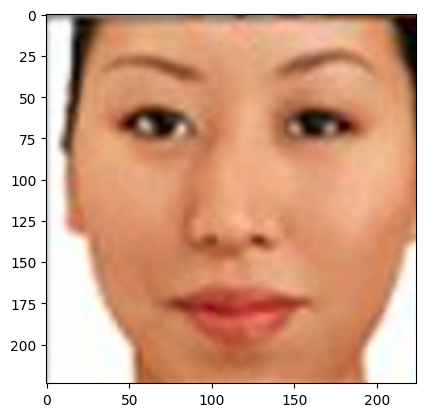

In [9]:
test_path = './imgs/'
test_files = os.listdir(test_path)

test_img = []

for i in test_files:
    img = os.path.join(test_path,i)
    test_img.append(img)

# print(test_img)

image_list = []
blankImages = []
images = []
for i, file in enumerate(test_img):
    origImg = cv2.imread(file)
    image_list.append(origImg)
    img = extract_face(origImg)
    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB));
    
    blankImage = handle_skin(img)
    colors = get_average_skin_color(img) # BGR
    # print(colors)
    
    blankImages.append(blankImage)
    images.append(img)
    # print("IMG: ", img, len(img), blankImage, len(blankImage))

    avg = getAvg(img, blankImage)
    print(file, avg)
    if 'coolFair1' in file:
        coolFair1.append(avg)
    elif 'coolFair2' in file:
        coolFair2.append(avg)
    elif 'neutralFair1' in file:
        neutralFair1.append(avg)
    elif 'neutralFair2' in file:
        neutralFair2.append(avg)
    elif 'warmFair1' in file:
        warmFair1.append(avg)
    elif 'warmFair2' in file:
        warmFair2.append(avg)
    elif 'coolLight1' in file:
        coolLight1.append(avg)
    elif 'coolLight2' in file:
        coolLight2.append(avg)
    elif 'neutralLight1' in file:
        neutralLight1.append(avg)
    elif 'neutralLight2' in file:
        neutralLight2.append(avg)
    elif 'warmLight1' in file:
        warmLight1.append(avg)
    elif 'warmLight2' in file:
        warmLight2.append(avg)
    elif 'coolMedium1' in file:
        coolMedium1.append(avg)
    elif 'coolMedium2' in file:
        coolMedium2.append(avg)
    elif 'neutralMedium1' in file:
        neutralMedium1.append(avg)
    elif 'neutralMedium2' in file:
        neutralMedium2.append(avg)
    elif 'warmMedium1' in file:
        warmMedium1.append(avg)
    elif 'warmMedium2' in file:
        warmMedium2.append(avg)
    elif 'coolTan1' in file or 'tanCool1' in file:
        coolTan1.append(avg)
    elif 'coolTan2' in file or 'tanCool2' in file:
        coolTan2.append(avg)
    elif 'neutralTan1' in file or 'tanNeutral1' in file:
        neutralTan1.append(avg)
    elif 'neutralTan2' in file or 'tanNeutral2' in file:
        neutralTan2.append(avg)
    elif 'warmTan1' in file or 'tanWarm1' in file:
        warmTan1.append(avg)
    elif 'warmTan2' in file or 'tanWarm2' in file:
        warmTan2.append(avg)
    elif 'coolDeep1' in file or 'deepCool1' in file:
        coolDeep1.append(avg)
    elif 'coolDeep2' in file or 'deepCool2' in file:
        coolDeep2.append(avg)
    elif 'neutralDeep1' in file or 'deepNeutral1' in file:
        neutralDeep1.append(avg)
    elif 'neutralDeep2' in file or 'deepNeutral2' in file:
        neutralDeep2.append(avg)
    elif 'warmDeep1' in file or 'deepWarm1' in file:
        warmDeep1.append(avg)
    elif 'warmDeep2' in file or 'deepWarm2' in file:
        warmDeep2.append(avg)
    
    # if 'coolFair1' in file:
    #     coolFair1.append(colors)
    # elif 'coolFair2' in file:
    #     coolFair2.append(colors)
    # elif 'neutralFair1' in file:
    #     neutralFair1.append(colors)
    # elif 'neutralFair2' in file:
    #     neutralFair2.append(colors)
    # elif 'warmFair1' in file:
    #     warmFair1.append(colors)
    # elif 'warmFair2' in file:
    #     warmFair2.append(colors)
    # elif 'coolLight1' in file:
    #     coolLight1.append(colors)
    # elif 'coolLight2' in file:
    #     coolLight2.append(colors)
    # elif 'neutralLight1' in file:
    #     neutralLight1.append(colors)
    # elif 'neutralLight2' in file:
    #     neutralLight2.append(colors)
    # elif 'warmLight1' in file:
    #     warmLight1.append(colors)
    # elif 'warmLight2' in file:
    #     warmLight2.append(colors)
    # elif 'coolMedium1' in file:
    #     coolMedium1.append(colors)
    # elif 'coolMedium2' in file:
    #     coolMedium2.append(colors)
    # elif 'neutralMedium1' in file:
    #     neutralMedium1.append(colors)
    # elif 'neutralMedium2' in file:
    #     neutralMedium2.append(colors)
    # elif 'warmMedium1' in file:
    #     warmMedium1.append(colors)
    # elif 'warmMedium2' in file:
    #     warmMedium2.append(colors)
    # elif 'coolTan1' in file or 'tanCool1' in file:
    #     coolTan1.append(colors)
    # elif 'coolTan2' in file or 'tanCool2' in file:
    #     coolTan2.append(colors)
    # elif 'neutralTan1' in file or 'tanNeutral1' in file:
    #     neutralTan1.append(colors)
    # elif 'neutralTan2' in file or 'tanNeutral2' in file:
    #     neutralTan2.append(colors)
    # elif 'warmTan1' in file or 'tanWarm1' in file:
    #     warmTan1.append(colors)
    # elif 'warmTan2' in file or 'tanWarm2' in file:
    #     warmTan2.append(colors)
    # elif 'coolDeep1' in file or 'deepCool1' in file:
    #     coolDeep1.append(colors)
    # elif 'coolDeep2' in file or 'deepCool2' in file:
    #     coolDeep2.append(colors)
    # elif 'neutralDeep1' in file or 'deepNeutral1' in file:
    #     neutralDeep1.append(colors)
    # elif 'neutralDeep2' in file or 'deepNeutral2' in file:
    #     neutralDeep2.append(colors)
    # elif 'warmDeep1' in file or 'deepWarm1' in file:
    #     warmDeep1.append(colors)
    # elif 'warmDeep2' in file or 'deepWarm2' in file:
    #     warmDeep2.append(colors)

print(len(image_list))


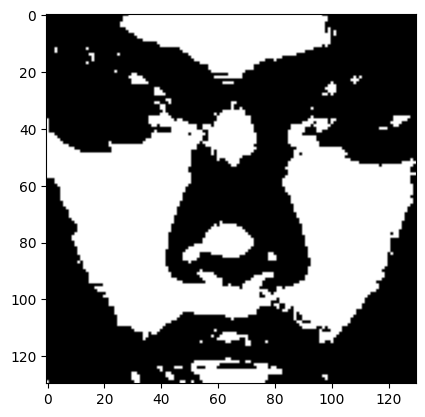

In [10]:
crop = blankImages[3][minIndexForFace:maxIndexForFace, minIndexForFace:maxIndexForFace]   
plt.imshow(cv2.cvtColor(crop,cv2.COLOR_BGR2RGB));

224
224


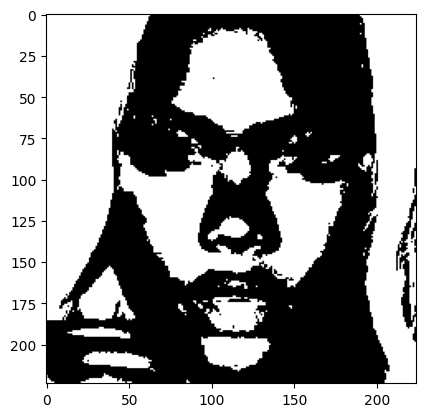

In [11]:
plt.imshow(cv2.cvtColor(blankImages[3],cv2.COLOR_BGR2RGB));
print(len(blankImages[3]))
print(len(blankImages[3][0]))

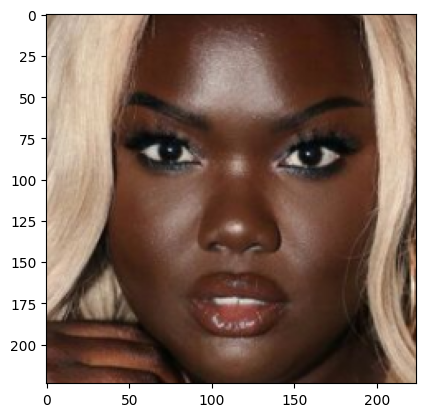

In [12]:
plt.imshow(cv2.cvtColor(images[3],cv2.COLOR_BGR2RGB));

In [13]:
def categAvg(categ):
    red = 0
    green =0
    blue = 0
    nr =0 
    for i in range(len(categ)):
        nr+=1
        red+= categ[i][0]
        green += categ[i][1]
        blue += categ[i][2]

    return "#{:02x}{:02x}{:02x}".format(round(red/nr), round(green/nr), round(blue/nr))
    # return [round(red/nr), round(green/nr), round(blue/nr)]

In [14]:
print(coolFair1)
coolFair1Avg = categAvg(coolFair1)
coolFair1Avg

[[215, 160, 155], [230, 184, 181], [207, 176, 173], [200, 162, 160]]


'#d5aaa7'

In [15]:
print(coolFair2)
coolFair2Avg = categAvg(coolFair2)
coolFair2Avg

[[241, 191, 178], [216, 166, 150], [215, 161, 132], [210, 174, 155], [220, 162, 144]]


'#dcab98'

In [16]:
print(neutralFair1)
neutralFair1Avg = categAvg(neutralFair1)
neutralFair1Avg

[[210, 148, 124]]


'#d2947c'

In [17]:
print(neutralFair2)
neutralFair2Avg = categAvg(neutralFair2)
neutralFair2Avg

[[211, 148, 128], [210, 143, 136]]


'#d29284'

In [18]:
print(warmFair1)
warmFair1Avg = categAvg(warmFair1)
warmFair1Avg

[[210, 152, 147], [232, 188, 171], [221, 169, 144]]


'#ddaa9a'

In [19]:
print(warmFair2)
warmFair2Avg = categAvg(warmFair2)
warmFair2Avg

[[232, 179, 162], [244, 185, 156], [222, 170, 144]]


'#e9b29a'

In [20]:
print(coolLight1)
coolLight1Avg = categAvg(coolLight1)
coolLight1Avg

[[195, 128, 123]]


'#c3807b'

In [21]:
print(coolLight2)
coolLight2Avg = categAvg(coolLight2)
coolLight2Avg

[[222, 171, 162]]


'#deaba2'

In [22]:
print(neutralLight1)
neutralLight1Avg = categAvg(neutralLight1)
neutralLight1Avg

[[199, 130, 117], [201, 135, 111], [226, 165, 136]]


'#d18f79'

In [23]:
print(neutralLight2)
neutralLight2Avg = categAvg(neutralLight2)
neutralLight2Avg

[[206, 137, 123], [222, 144, 125]]


'#d68c7c'

In [24]:
print(warmLight1)
warmLight1Avg = categAvg(warmLight1)
warmLight1Avg

[[202, 125, 113], [216, 146, 135], [204, 132, 123], [218, 144, 133], [208, 138, 130]]


'#d2897f'

In [25]:
print(warmLight2)
warmLight2Avg = categAvg(warmLight2)
warmLight2Avg

[[217, 152, 125], [212, 147, 116], [209, 146, 114], [208, 144, 116]]


'#d49376'

In [26]:
print(coolMedium1)
coolMedium1Avg = categAvg(coolMedium1)
coolMedium1Avg

[[179, 105, 77]]


'#b3694d'

In [27]:
print(coolMedium2)
coolMedium2Avg = categAvg(coolMedium2)
coolMedium2Avg

[[194, 128, 94]]


'#c2805e'

In [28]:
print(neutralMedium1)
neutralMedium1Avg = categAvg(neutralMedium1)
neutralMedium1Avg

[[214, 127, 108], [208, 146, 124]]


'#d38874'

In [29]:
print(neutralMedium2)
neutralMedium2Avg = categAvg(neutralMedium2)
neutralMedium2Avg

[[212, 141, 108], [222, 162, 137]]


'#d9987a'

In [30]:
print(warmMedium1)
warmMedium1Avg = categAvg(warmMedium1)
warmMedium1Avg

[[198, 124, 95], [222, 157, 129], [232, 158, 136]]


'#d99278'

In [31]:
print(warmMedium2)
warmMedium2Avg = categAvg(warmMedium2)
warmMedium2Avg

[[226, 149, 117], [210, 136, 121], [213, 144, 106]]


'#d88f73'

In [32]:
print(coolTan1)
coolTan1Avg = categAvg(coolTan1)
coolTan1Avg

[[210, 151, 127], [219, 152, 108]]


'#d69876'

In [33]:
print(coolTan2)
coolTan2Avg = categAvg(coolTan2)
coolTan2Avg

[[183, 102, 87]]


'#b76657'

In [34]:
print(neutralTan1)
neutralTan1Avg = categAvg(neutralTan1)
neutralTan1Avg

[[182, 101, 82], [185, 103, 90]]


'#b86656'

In [35]:
print(neutralTan2)
neutralTan2Avg = categAvg(neutralTan2)
neutralTan2Avg

[[184, 110, 82], [197, 126, 112], [192, 122, 88]]


'#bf775e'

In [36]:
print(warmTan1)
warmTan1Avg = categAvg(warmTan1)
warmTan1Avg

[[162, 106, 76], [182, 99, 85], [201, 122, 85], [185, 117, 88]]


'#b66f54'

In [37]:
print(warmTan2)
warmTan2Avg = categAvg(warmTan2)
warmTan2Avg

[[217, 145, 109], [166, 96, 65], [183, 115, 85], [170, 98, 71]]


'#b87252'

In [38]:
print(coolDeep1)
coolDeep1Avg = categAvg(coolDeep1)
coolDeep1Avg

[[119, 78, 96], [131, 89, 78]]


'#7d5457'

In [39]:
print(coolDeep2)
coolDeep2Avg = categAvg(coolDeep2)
coolDeep2Avg

[[162, 94, 63], [156, 85, 59], [165, 97, 73]]


'#a15c41'

In [40]:
print(neutralDeep1)
neutralDeep1Avg = categAvg(neutralDeep1)
neutralDeep1Avg

[[137, 94, 88]]


'#895e58'

In [41]:
print(neutralDeep2)
neutralDeep2Avg = categAvg(neutralDeep2)
neutralDeep2Avg

[[150, 88, 62]]


'#96583e'

In [42]:
print(warmDeep1)
warmDeep1Avg = categAvg(warmDeep1)
warmDeep1Avg

[[140, 83, 83], [150, 101, 89], [201, 124, 103]]


'#a4675c'

In [43]:
print(warmDeep2)
warmDeep2Avg = categAvg(warmDeep2)
warmDeep2Avg

[[173, 101, 87], [173, 97, 77], [152, 87, 60]]


'#a65f4b'

In [44]:
print('-------------------------------------------------------')

strs = ["coolFair1","coolFair2","neutralFair1","neutralFair2","warmFair1","warmFair2","coolLight1","coolLight2","neutralLight1","neutralLight2","warmLight1","warmLight2","coolMedium1","coolMedium2","neutralMedium1","neutralMedium2","warmMedium1","warmMedium2","coolTan1","coolTan2","neutralTan1","neutralTan2","warmTan1","warmTan2","coolDeep1","coolDeep2","neutralDeep1","neutralDeep2","warmDeep1","warmDeep2"]
referenceColors = [coolFair1Avg,coolFair2Avg,neutralFair1Avg,neutralFair2Avg, warmFair1Avg, warmFair2Avg,coolLight1Avg,coolLight2Avg,neutralLight1Avg,neutralLight2Avg, warmLight1Avg,warmLight2Avg,coolMedium1Avg,coolMedium2Avg, neutralMedium1Avg,neutralMedium2Avg,warmMedium1Avg,warmMedium2Avg,coolTan1Avg,coolTan2Avg,neutralTan1Avg,neutralTan2Avg,warmTan1Avg,warmTan2Avg,coolDeep1Avg,coolDeep2Avg,neutralDeep1Avg,neutralDeep2Avg,warmDeep1Avg,warmDeep2Avg]
referenceColors

-------------------------------------------------------


['#d5aaa7',
 '#dcab98',
 '#d2947c',
 '#d29284',
 '#ddaa9a',
 '#e9b29a',
 '#c3807b',
 '#deaba2',
 '#d18f79',
 '#d68c7c',
 '#d2897f',
 '#d49376',
 '#b3694d',
 '#c2805e',
 '#d38874',
 '#d9987a',
 '#d99278',
 '#d88f73',
 '#d69876',
 '#b76657',
 '#b86656',
 '#bf775e',
 '#b66f54',
 '#b87252',
 '#7d5457',
 '#a15c41',
 '#895e58',
 '#96583e',
 '#a4675c',
 '#a65f4b']

In [45]:
def hex_to_rgb(hex_color):
    # Remove the '#' character if present
    hex_color = hex_color.lstrip('#')
    
    # Convert the hex color to RGB values
    rgb_values = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    
    return rgb_values

./imgs/02.AlexandraUrsu.png [195, 144, 130] [np.float64(171.26377796056997), np.float64(123.92904715153766), np.float64(104.57733435932815)]
Predicted:  neutralFair2 233
./imgs/AlexandraUrsu.jpeg [168, 127, 115] [np.float64(146.07815253346524), np.float64(110.69255263239249), np.float64(98.69601508640677)]
Predicted:  coolLight1 794
./imgs/AlexandraUrsu2.png [195, 144, 130] [np.float64(173.8442473671708), np.float64(126.18578932087523), np.float64(106.87101116477947)]
Predicted:  neutralFair2 233
./imgs/blackBlonde3.jpg [128, 93, 80] [np.float64(135.05980829658577), np.float64(103.58878825486521), np.float64(87.11182699162948)]
Predicted:  coolDeep1 139
./imgs/coolFair1_1.png [215, 160, 155] [np.float64(207.6452698385654), np.float64(155.59407079269073), np.float64(146.55833368829067)]
Predicted:  warmFair1 137
./imgs/coolFair1_2.png [230, 184, 181] [np.float64(213.45186270917307), np.float64(173.51017466715524), np.float64(164.12766581165263)]
Predicted:  coolLight2 594
./imgs/coolFai

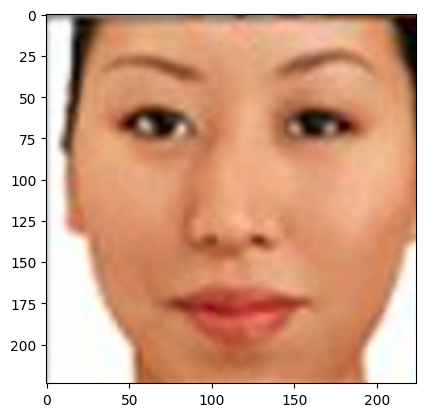

In [46]:
for i, file in enumerate(test_img):
    origImg = cv2.imread(file)
    img = extract_face(origImg)
    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB));
    
    blankImage = handle_skin(img)
    avg = getAvg(img, blankImage)
    colors = get_average_skin_color(img) # BGR

    print(file, avg, colors)

    minDif = 999999
    nearest = ''

    red = avg[0]
    green = avg[1]
    blue = avg[2]


    # red = colors[0]
    # green = colors[1]
    # blue = colors[2]
    
    for i in range(len(strs)):
        rgb_values = hex_to_rgb(referenceColors[i])
        referenceRed = rgb_values[0]
        referenceGreen = rgb_values[1]
        referenceBlue = rgb_values[2]
        # print(referenceRed, referenceGreen, referenceBlue)
        # dist = (referenceRed - imageRed)**2 + (referenceGreen - imageGreen)**2 + (referenceBlue - imageBlue)**2
        dist = (red - referenceRed)**2 + (green - referenceGreen)**2 + (blue - referenceBlue)**2
        if dist < minDif:
            minDif = dist
            nearest = strs[i]
        
    print('Predicted: ', nearest, minDif)